In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
customer_df = pd.json_normalize(df['customer'])
df = df.drop(columns=['customer']).join(customer_df)

phone_df = pd.json_normalize(df['phone'])
df = df.drop(columns=['phone']).join(phone_df)

internet_df = pd.json_normalize(df['internet'])
df = df.drop(columns=['internet']).join(internet_df)

account_df = pd.json_normalize(df['account'])
df = df.drop(columns=['account']).join(account_df)

In [5]:
df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


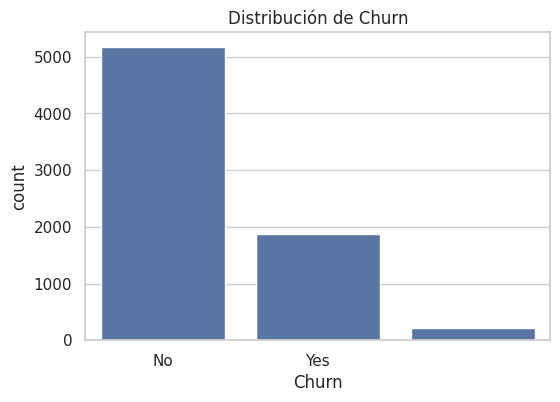

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Distribución de Churn")
plt.show()

df['Churn'].value_counts(normalize=True) * 100

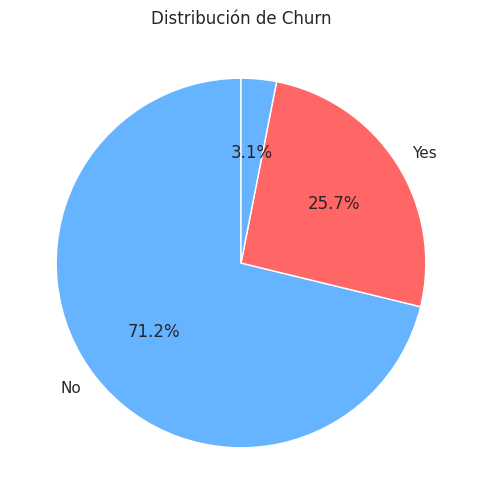

In [9]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title("Distribución de Churn")
plt.show()

1. Introducción

El presente análisis tiene como objetivo identificar los factores que influyen en la evasión de clientes (Churn) de Telecom X. La empresa enfrenta una alta tasa de cancelaciones, y comprender el comportamiento de los clientes permitirá:

Detectar patrones asociados al Churn.

Preparar estrategias de retención efectivas.

Apoyar modelos predictivos para prevenir la pérdida de clientes.

2. Limpieza y Tratamiento de Datos

Se realizaron los siguientes pasos:

Importación de datos desde la API en formato JSON y carga en Pandas.

Exploración inicial con df.info(), df.head() y df.isnull().sum().

Aplanamiento de columnas con diccionarios (customer, phone, internet, account) usando pd.json_normalize.

Verificación y manejo de duplicados con df.duplicated().sum().

Conversión de variables binarias a 0/1 para análisis cuantitativo.

Conversión de columnas numéricas (tenure, Charges.Monthly, Charges.Total) a tipo float.

Relleno de valores faltantes con la mediana en columnas numéricas, si era necesario.

import pandas as pd

# Convertir variables binarias
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

# Convertir Churn a 0/1
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Convertir columnas numéricas a float
numeric_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)
3. Análisis Exploratorio de Datos (EDA)
3.1 Distribución general de Churn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Gráfico de pastel
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['No Churn','Churn'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title("Distribución de Churn")
plt.show()
3.2 Churn según variables categóricas (porcentaje de Churn)
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    churn_pct = df.groupby(col)['Churn'].mean() * 100
    churn_pct.sort_values(ascending=False).plot(kind='bar', color='#ff9999')
    plt.ylabel('% de Churn')
    plt.title(f"Porcentaje de Churn según {col}")
    plt.xticks(rotation=45)
    plt.show()

Observación: Clientes con contratos “Month-to-month”, sin soporte técnico o sin servicios de seguridad online presentan mayor tasa de Churn.

3.3 Churn según variables numéricas (violín plots)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(x='Churn', y=col, data=df, palette=['#66b3ff','#ff6666'])
    plt.title(f"Distribución de {col} según Churn")
    plt.show()

Observación: Los clientes con menor tiempo de permanencia (tenure) o con cargos más altos (Charges.Monthly) muestran mayor probabilidad de abandonar el servicio.

4. Conclusiones e Insights

La duración del contrato (tenure) es determinante: clientes con menor tiempo tienen mayor riesgo de Churn.

Los contratos mensuales (Month-to-month) tienen más cancelaciones que los contratos anuales.

La presencia de servicios adicionales como soporte técnico, seguridad online y protección de dispositivos disminuye la evasión.

Clientes con altos cargos mensuales o patrones específicos de pago presentan mayor riesgo de abandono.

La combinación de características demográficas y de servicio ayuda a identificar clientes en riesgo.

5. Recomendaciones

Incentivar contratos más largos con promociones o beneficios para reducir la tasa de Churn.

Promover la contratación de servicios adicionales, como soporte técnico y seguridad online.

Implementar un programa de retención para clientes nuevos con bajo tenure o contratos mensuales.

Analizar los métodos de pago y facturación para mejorar la experiencia y disminuir la evasión.

Monitorear periódicamente los clientes de mayor riesgo y ofrecer incentivos personalizados.